In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Text(0, 0.5, 'Price')

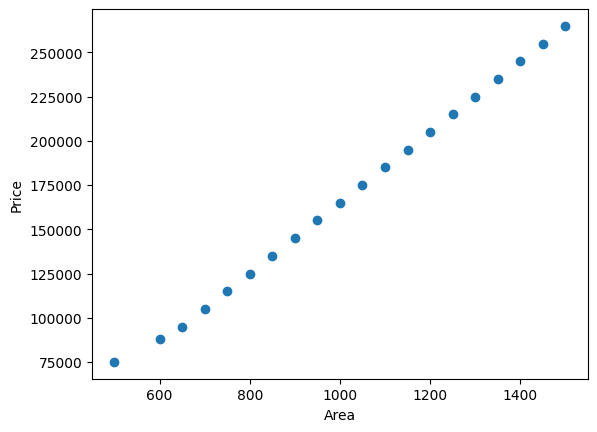

In [5]:
data=pd.read_csv('data/housing.csv')
plt.scatter(data['area'], data['price'])
plt.xlabel('Area')
plt.ylabel('Price')

In [15]:
x=data['area'].values
y=data['price'].values


In [29]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test=train_test_split(x, y, test_size=0.2)

In [31]:
len(x_train)

16

In [32]:
cov_xy=np.mean(x_train*y_train)-np.mean(x_train)*np.mean(y_train)
var_x=np.mean(x_train**2)-np.mean(x_train)**2

In [33]:
b1=cov_xy/var_x
b0=np.mean(y_train)-b1*np.mean(x_train)
b1, b0

(np.float64(195.01862197392924), np.float64(-29019.320297951577))

In [19]:
from sklearn.linear_model import LinearRegression
lin_reg=LinearRegression()

In [34]:
lin_reg.fit(x_train.reshape(-1, 1), y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [35]:
lin_reg.coef_

array([195.01862197])

In [36]:
lin_reg.intercept_

np.float64(-29019.320297951665)

In [44]:
y_pred=lin_reg.predict(x_test.reshape(-1,1))
y_pred


array([195252.09497207, 234255.81936685, 107493.7150838 ,  97742.7839851 ])

In [41]:
y_test

array([195000, 235000, 105000,  95000])

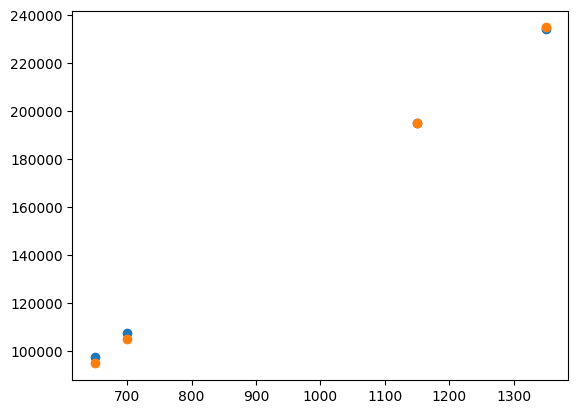

In [45]:
plt.scatter(x_test, y_pred)
plt.scatter(x_test, y_test)

In [46]:
mae=np.mean(abs(y_test-y_pred))
mae

np.float64(1558.1936685288456)

In [48]:
mse=np.mean((y_test-y_pred)**2)
mse

np.float64(3589708.899448202)

In [51]:
R_square=lin_reg.score(x_test.reshape(-1,1), y_test)
R_square

0.9989798340605476

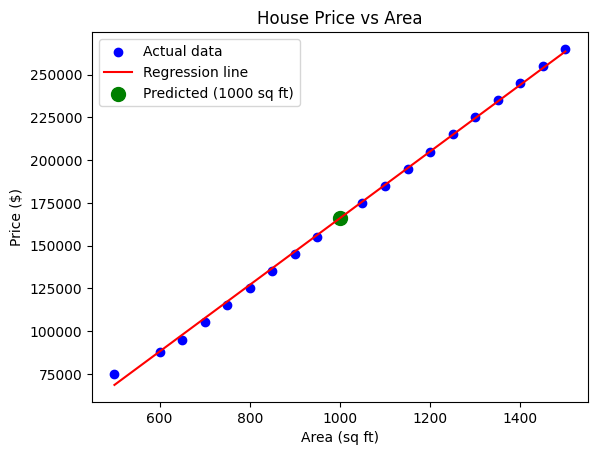

In [ ]:
plt.scatter(x, y, color='blue', label='Actual data')
all_pred_y=lin_reg.predict(x.reshape(-1,1))
plt.plot(x, all_pred_y, color='red', label='Regression line')
pred_1000=lin_reg.predict([[1000]])
plt.scatter(1000, pred_1000, color='green', s=100, label='Predicted (1000 sq ft)')

plt.xlabel('Area (sq ft)')
plt.ylabel('Price ($)')
plt.title('House Price vs Area')
plt.legend()
plt.show()
#yes, prediction for 1000 sq ft seems reasonable according to graph and actual price